<a href="https://colab.research.google.com/github/Mansik-04/assignments/blob/main/svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What is a Support Vector Machine (SVM)?
A supervised learning algorithm for classification and regression that finds a decision boundary (hyperplane) maximizing the margin between classes. The points that determine the margin are called support vectors.

Hard Margin vs Soft Margin SVM

Hard margin: requires perfect separation (no errors) — only possible if data is linearly separable.

Soft margin: allows misclassifications via slack variables; controlled by parameter C to trade off margin width vs classification errors.
Role of Lagrange Multipliers
Convert constrained optimization to unconstrained dual problem. Lagrange multipliers
𝛼
𝑖
α
i
	​

 show which points are support vectors (
𝛼
𝑖
>
0
α
i
	​

>0). The dual also enables kernelization.

Support Vectors
Training samples with non-zero Lagrange multipliers; they lie on or inside the margin and uniquely determine the decision boundary.

Support Vector Classifier (SVC)
The SVM formulation for classification (often refers to soft-margin classifier implemented in libraries).

Support Vector Regressor (SVR)
Use SVM principles for regression: find a function within an epsilon-tube of the target; slack variables penalize points outside epsilon.

Kernel Trick
Implicitly map data into a high-dimensional space using kernel function ) so inner products are computed without explicit mapping.

Compare Linear, Polynomial, RBF kernels

Linear: no mapping — good for linearly separable data or high-dimensional sparse data.

Polynomial: captures polynomial relationships; controlled by degree d.

RBF (Gaussian): localized decision boundaries; controlled by gamma. Very flexible.

Effect of C parameter

Large C: low regularization → small margin, fewer misclassifications on training (risk overfitting).

Small C: more regularization → wider margin, allows more training errors.

Role of gamma (in RBF)

Large gamma: small radius of influence, more complex decision boundary (risk overfitting).

Small gamma: smoother decision boundary.

What is Naïve Bayes & why "naïve"
Probabilistic classifier using Bayes’ theorem with the naïve assumption that features are conditionally independent given the class.

Gaussian vs Multinomial vs Bernoulli Naïve Bayes

GaussianNB: features are continuous and assumed to follow Gaussian distribution.

MultinomialNB: counts/features (e.g., word counts) — suitable for document classification.

BernoulliNB: binary features (presence/absence) — suitable for binary word occurrence features.

When to use GaussianNB
Use when features are continuous and roughly normally distributed.

Key assumptions
Conditional independence of features given class; correct form of likelihood (e.g., Gaussian).

Advantages & disadvantages

Fast, simple, works well with high-dimensional data, performs well with small data.
− Strong independence assumption, poor at modeling correlated features.

Why Naïve Bayes for text classification
Works well with high-dimensional sparse data, handles word counts naturally (MultinomialNB), fast training and inference.

Compare SVM vs Naïve Bayes

SVM: margin-based, often better with clear class separation, needs careful kernel / scaling, slower to train on large datasets.

Naïve Bayes: probabilistic, simpler, very fast, can perform well in text tasks despite naive assumption.

Laplace smoothing in Naïve Bayes
Adds a small constant (usually 1) to counts to avoid zero probabilities for unseen features in classes.

Iris SVM accuracy: 0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Wine Linear SVM acc: 0.9444444444444444
Wine RBF SVM acc: 0.9722222222222222
SVR MSE: 0.3570026426754463


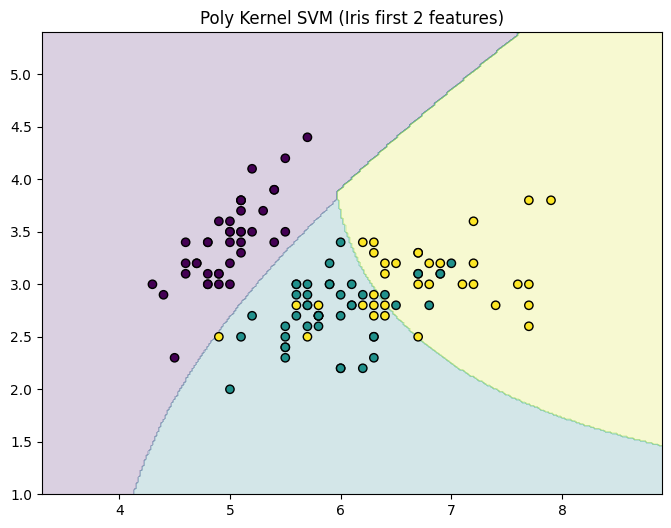

Poly kernel accuracy (2 features): 0.7
GaussianNB accuracy (Breast Cancer): 0.9385964912280702
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

MultinomialNB text accuracy (subset): 0.8674698795180723
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       195
           1       0.88      0.90      0.89       200
           2       0.95      0.75      0.84       197
           3       0.74      0.92      0.82       155

    accuracy                           0.87       747
   macro avg       0.87      0.87      0.87       747
weighted avg       0.88      0.87      0.87       747



In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine, load_breast_cancer, fetch_california_housing, fetch_20newsgroups
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, precision_recall_fscore_support, roc_auc_score, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.utils import class_weight
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# For reproducibility
RANDOM_STATE = 42
#A. 1 — Train an SVM Classifier on Iris and evaluate accuracy

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=RANDOM_STATE, stratify=y)

svc = SVC(kernel='rbf', random_state=RANDOM_STATE)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
print("Iris SVM accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=iris.target_names))

#A.2 — Train two SVMs (Linear vs RBF) on Wine dataset and compare

wine = load_wine()
Xw, yw = wine.data, wine.target
Xw_train, Xw_test, yw_train, yw_test = train_test_split(Xw, yw, test_size=0.2, random_state=RANDOM_STATE, stratify=yw)
scaler = StandardScaler()
Xw_train_s = scaler.fit_transform(Xw_train)
Xw_test_s = scaler.transform(Xw_test)

svc_linear = SVC(kernel='linear', random_state=RANDOM_STATE)
svc_rbf = SVC(kernel='rbf', random_state=RANDOM_STATE)
svc_linear.fit(Xw_train_s, yw_train)
svc_rbf.fit(Xw_train_s, yw_train)
print("Wine Linear SVM acc:", accuracy_score(yw_test, svc_linear.predict(Xw_test_s)))
print("Wine RBF SVM acc:", accuracy_score(yw_test, svc_rbf.predict(Xw_test_s)))

#A.3 — Train SVR on housing dataset and evaluate MSE
house = fetch_california_housing()
Xh, yh = house.data, house.target
Xh_train, Xh_test, yh_train, yh_test = train_test_split(Xh, yh, test_size=0.2, random_state=RANDOM_STATE)
scaler_h = StandardScaler()
Xh_train_s = scaler_h.fit_transform(Xh_train)
Xh_test_s = scaler_h.transform(Xh_test)

svr = SVR(kernel='rbf')
svr.fit(Xh_train_s, yh_train)
yh_pred = svr.predict(Xh_test_s)
print("SVR MSE:", mean_squared_error(yh_test, yh_pred))

#A.4 — Polynomial kernel SVM + visualize decision boundary (2D)
# Use Iris first two features for 2D plotting
X2 = iris.data[:, :2]
y2 = iris.target
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2,test_size=0.2, random_state=RANDOM_STATE, stratify=y2)

svc_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='auto')
svc_poly.fit(X2_train, y2_train)

# Plot decision boundary
def plot_decision_boundary(clf, X, y, ax=None, title='Decision boundary'):
    ax = ax or plt.gca()
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2)
    scatter = ax.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
    ax.set_title(title)
    return ax

plt.figure(figsize=(8,6))
plot_decision_boundary(svc_poly, X2_train, y2_train, title='Poly Kernel SVM (Iris first 2 features)')
plt.show()

print("Poly kernel accuracy (2 features):", accuracy_score(y2_test, svc_poly.predict(X2_test)))


#A.5 — Gaussian Naïve Bayes on Breast Cancer dataset
bc = load_breast_cancer()
Xc, yc = bc.data, bc.target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc,yc,test_size=0.2, random_state=RANDOM_STATE, stratify=yc)

gnb = GaussianNB()
gnb.fit(Xc_train, yc_train)
yc_pred = gnb.predict(Xc_test)
print("GaussianNB accuracy (Breast Cancer):", accuracy_score(yc_test, yc_pred))
print(classification_report(yc_test, yc_pred))

#A.6 — Multinomial Naïve Bayes for text (20 Newsgroups)
newsgroups = fetch_20newsgroups(subset='all', categories=['rec.sport.hockey','sci.space','comp.graphics','talk.politics.misc'], remove=('headers','footers','quotes'))
X_text = newsgroups.data
y_text = newsgroups.target

# Simple pipeline
pipeline = Pipeline([
    ('vect', CountVectorizer(stop_words='english', max_features=5000)),
    ('clf', MultinomialNB())
])
X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(X_text,y_text,test_size=0.2, random_state=RANDOM_STATE, stratify=y_text)
pipeline.fit(X_text_train, y_text_train)
y_text_pred = pipeline.predict(X_text_test)
print("MultinomialNB text accuracy (subset):", accuracy_score(y_text_test, y_text_pred))
print(classification_report(y_text_test, y_text_pred))